# 05_05 Two-stage LightGBM feature-group ablation

This notebook tests whether the **spoilage** and **goods-receipt** feature groups reduce out-of-sample error in the selected two-stage occurrence × positive-quantity LightGBM. It runs a complete 2 × 2 ablation: all features, all except spoilage, all except goods receipts, and all except both groups.

The four variants use identical expanding training windows, validation windows, evaluation origins, hyperparameters, random seed, and target rows. Therefore, the only experimental difference is the included feature set.

## Interpretation

The primary metric is pooled WAPE over active evaluation rows. For a feature group, `error decrease` is defined as the ablated model's WAPE minus the richer model's WAPE. A positive value means adding the group decreased error; a negative value means it increased error.

Because the two groups may overlap in information, each is measured both with and without the other group present. The paired bootstrap resamples the 20 evaluation origins and describes how stable the observed WAPE difference is across weeks; it is not a claim about independent future data.

In [1]:
from pathlib import Path
import gc
import os
import sys

os.environ.setdefault('MPLCONFIGDIR', '/tmp/ba-matplotlib')

import duckdb
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models.benchmark import load_benchmark_design, segment_wape, summarize_models
from src.models.lightgbm import FEATURE_COLUMNS, GlobalLightGBMConfig, fit_two_stage
from src.models.lightgbm.runner import iter_run_frames

pd.set_option('display.max_columns', 60)
pd.set_option('display.max_rows', 120)
sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 42
N_BOOTSTRAP = 5_000

In [2]:
SPOILAGE_FEATURES = (
    'spoilage_qty_last_28d',
    'spoilage_days_last_28d',
    'days_since_last_spoilage',
    'has_any_spoilage_history',
)
GOODS_RECEIPT_FEATURES = (
    'receipt_qty_pos_last_7d',
    'receipt_qty_pos_last_14d',
    'receipt_qty_pos_last_28d',
    'receipt_days_last_28d',
    'days_since_last_receipt',
    'receipt_qty_net_last_28d',
    'receipt_negative_qty_last_28d',
    'has_receipt_history',
)

def excluding(*groups):
    removed = set().union(*map(set, groups))
    return tuple(feature for feature in FEATURE_COLUMNS if feature not in removed)

VARIANT_FEATURES = {
    'all_features': tuple(FEATURE_COLUMNS),
    'without_spoilage': excluding(SPOILAGE_FEATURES),
    'without_goods_receipts': excluding(GOODS_RECEIPT_FEATURES),
    'without_both_groups': excluding(SPOILAGE_FEATURES, GOODS_RECEIPT_FEATURES),
}
VARIANT_LABELS = {
    'all_features': 'All features',
    'without_spoilage': 'Without spoilage',
    'without_goods_receipts': 'Without goods receipts',
    'without_both_groups': 'Without both groups',
}

assert set(SPOILAGE_FEATURES).issubset(FEATURE_COLUMNS)
assert set(GOODS_RECEIPT_FEATURES).issubset(FEATURE_COLUMNS)
assert set(SPOILAGE_FEATURES).isdisjoint(GOODS_RECEIPT_FEATURES)
assert all(len(features) == len(set(features)) for features in VARIANT_FEATURES.values())

feature_design = pd.DataFrame([
    {
        'variant': variant,
        'label': VARIANT_LABELS[variant],
        'features': len(features),
        'includes_spoilage': set(SPOILAGE_FEATURES).issubset(features),
        'includes_goods_receipts': set(GOODS_RECEIPT_FEATURES).issubset(features),
    }
    for variant, features in VARIANT_FEATURES.items()
])
display(feature_design)
print('Spoilage features:', ', '.join(SPOILAGE_FEATURES))
print('Goods-receipt features:', ', '.join(GOODS_RECEIPT_FEATURES))

,variant,label,features,includes_spoilage,includes_goods_receipts
0,all_features,All features,59,True,True
1,without_spoilage,Without spoilage,55,False,True
2,without_goods_receipts,Without goods receipts,51,True,False
3,without_both_groups,Without both groups,47,False,False


Spoilage features: spoilage_qty_last_28d, spoilage_days_last_28d, days_since_last_spoilage, has_any_spoilage_history
Goods-receipt features: receipt_qty_pos_last_7d, receipt_qty_pos_last_14d, receipt_qty_pos_last_28d, receipt_days_last_28d, days_since_last_receipt, receipt_qty_net_last_28d, receipt_negative_qty_last_28d, has_receipt_history


## Fit the four variants

Feature snapshots are generated once per origin and reused across variants. Each model is refitted every four evaluation origins, matching the main LightGBM experiment. Closed rows remain in the forecast output for alignment but are excluded from all accuracy metrics through `is_active`.

In [3]:
design = load_benchmark_design()
model_config = GlobalLightGBMConfig()
CACHE_RESULTS = True
CACHE_DIR = ROOT / 'data' / 'processed' / 'two_stage_feature_group_ablation' / 'v1'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
forecast_parts = []
importance_parts = []
training_parts = []

con = duckdb.connect()
con.execute("SET temp_directory='/tmp/ba_lightgbm_ablation_duckdb'")
con.execute(f'SET threads={model_config.num_threads}')
con.execute('SET preserve_insertion_order=false')
try:
    for refit_number, frames in enumerate(
        iter_run_frames(con, design, model_config), start=1
    ):
        evaluation_origin = pd.Timestamp(frames.evaluation_origin)
        for variant_number, (variant, feature_columns) in enumerate(
            VARIANT_FEATURES.items(), start=1
        ):
            cache_stem = f'{evaluation_origin.date()}__{variant}'
            forecast_cache = CACHE_DIR / f'{cache_stem}__forecasts.parquet'
            importance_cache = CACHE_DIR / f'{cache_stem}__importance.parquet'
            training_cache = CACHE_DIR / f'{cache_stem}__training.parquet'
            cache_paths = (forecast_cache, importance_cache, training_cache)
            if CACHE_RESULTS and all(path.exists() for path in cache_paths):
                print(
                    f'[refit {refit_number}/5, variant {variant_number}/4] '
                    f'Loading cached {VARIANT_LABELS[variant]} at '
                    f'{evaluation_origin.date()}'
                )
                forecast_parts.append(pd.read_parquet(forecast_cache))
                importance_parts.append(pd.read_parquet(importance_cache))
                training_parts.append(pd.read_parquet(training_cache))
                continue
            print(
                f'[refit {refit_number}/5, variant {variant_number}/4] '
                f'{VARIANT_LABELS[variant]} at {evaluation_origin.date()}'
            )
            result = fit_two_stage(
                frames, model_config, feature_columns=feature_columns
            )
            forecasts_part = result.forecasts.copy()
            forecasts_part['model'] = variant
            forecast_parts.append(forecasts_part)

            importance_part = result.feature_importance.copy()
            importance_part.insert(0, 'evaluation_origin', evaluation_origin)
            importance_part.insert(0, 'model', variant)
            importance_parts.append(importance_part)

            training_part = result.training_summary.copy()
            training_part['model'] = variant
            training_parts.append(training_part)
            if CACHE_RESULTS:
                forecasts_part.to_parquet(forecast_cache, index=False)
                importance_part.to_parquet(importance_cache, index=False)
                training_part.to_parquet(training_cache, index=False)
            del result
            gc.collect()
finally:
    con.close()

forecasts = pd.concat(forecast_parts, ignore_index=True)
feature_importance = pd.concat(importance_parts, ignore_index=True)
training_summary = pd.concat(training_parts, ignore_index=True)
del forecast_parts, importance_parts, training_parts

expected_rows = forecasts.loc[forecasts.model.eq('all_features')].shape[0]
assert forecasts.groupby('model').size().eq(expected_rows).all()
assert forecasts.groupby('model').origin.nunique().eq(model_config.test_origins).all()
assert training_summary.groupby(['model', 'stage']).size().eq(5).all()
print(f'Completed {len(VARIANT_FEATURES)} variants × {model_config.test_origins} origins.')

[data] Loading prepared daily demand rows from /Users/vlada/UNI/SoSe2026/ba/ba_code/data/processed/transactions...
[data] Using 20 evaluation origins from 2026-03-02 through 2026-07-13
[features] Preparing leakage-safe origin history...
[features] Reusing 72 cached origin partitions from /Users/vlada/UNI/SoSe2026/ba/ba_code/data/processed/model_features/lightgbm_daily/v1/e83253e74c052146e7fe
[frames 1/5] Loading train, validation, and evaluation rows for 2026-03-02 through 2026-03-23...
[frames 1/5] Ready: 5,375,438 training, 504,031 validation, and 603,925 evaluation rows
[refit 1/5, variant 1/4] Loading cached All features at 2026-03-02
[refit 1/5, variant 2/4] Loading cached Without spoilage at 2026-03-02
[refit 1/5, variant 3/4] Loading cached Without goods receipts at 2026-03-02
[refit 1/5, variant 4/4] Loading cached Without both groups at 2026-03-02
[frames 2/5] Loading train, validation, and evaluation rows for 2026-03-30 through 2026-04-20...
[frames 2/5] Ready: 5,879,469 trai

In [4]:
fit_audit = (
    training_summary.groupby(['model', 'stage'], observed=True)
    .agg(
        refits=('evaluation_origin', 'nunique'),
        features=('features', 'first'),
        mean_best_iteration=('best_iteration', 'mean'),
        min_best_iteration=('best_iteration', 'min'),
        max_best_iteration=('best_iteration', 'max'),
    )
    .reset_index()
)
fit_audit['variant'] = fit_audit.model.map(VARIANT_LABELS)
display(fit_audit[[
    'variant', 'stage', 'refits', 'features', 'mean_best_iteration',
    'min_best_iteration', 'max_best_iteration',
]].style.format({
    'refits': '{:,.0f}', 'features': '{:,.0f}',
    'mean_best_iteration': '{:.1f}', 'min_best_iteration': '{:,.0f}',
    'max_best_iteration': '{:,.0f}',
}))

,variant,stage,refits,features,mean_best_iteration,min_best_iteration,max_best_iteration
0,All features,occurrence,5,59,297.8,215,500
1,All features,positive_quantity,5,59,287.0,156,500
2,Without both groups,occurrence,5,47,312.0,253,399
3,Without both groups,positive_quantity,5,47,338.2,148,499
4,Without goods receipts,occurrence,5,51,339.6,259,473
5,Without goods receipts,positive_quantity,5,51,339.8,148,496
6,Without spoilage,occurrence,5,55,348.2,205,472
7,Without spoilage,positive_quantity,5,55,325.6,158,500


## Overall error

Lower WAPE, seasonal MASE, and MAE are better. Relative bias is included to reveal whether an apparent error improvement comes with systematic under- or overforecasting.

,variant,pooled_wape,seasonal_mase,mae_kg,relative_bias,forecast_to_actual_ratio,actual_kg,forecast_kg,n_series,n_origins,n_forecast_rows
0,Without spoilage,58.089%,0.6660,0.5905,-0.736%,0.9926,"2,552,925.9","2,534,145.9","21,937",20,"2,511,229"
1,Without goods receipts,58.124%,0.6674,0.5909,-1.103%,0.9890,"2,552,925.9","2,524,772.7","21,937",20,"2,511,229"
2,Without both groups,58.179%,0.6672,0.5915,-1.660%,0.9834,"2,552,925.9","2,510,546.0","21,937",20,"2,511,229"
3,All features,58.362%,0.6683,0.5933,-0.824%,0.9918,"2,552,925.9","2,531,900.7","21,937",20,"2,511,229"


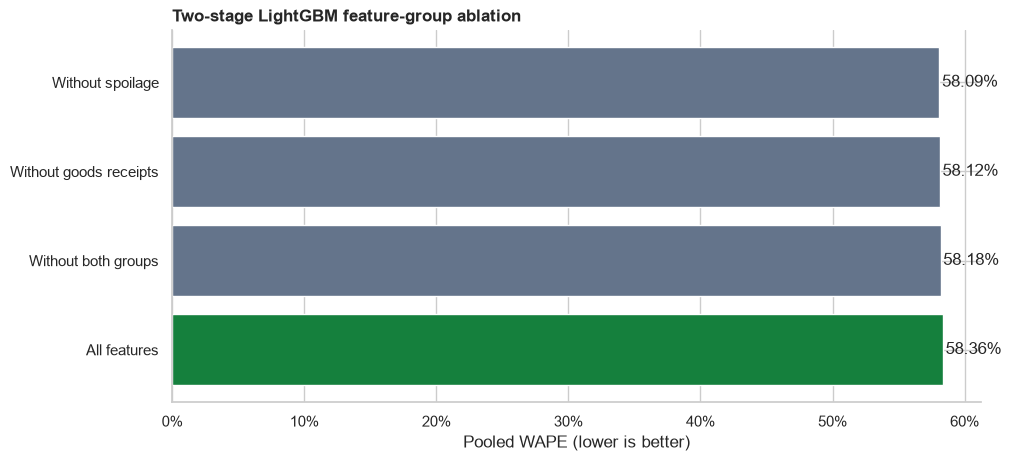

In [5]:
overall = summarize_models(forecasts)
overall['variant'] = overall.model.map(VARIANT_LABELS)
overall = overall.sort_values('pooled_wape').reset_index(drop=True)
display(overall[[
    'variant', 'pooled_wape', 'seasonal_mase', 'mae_kg',
    'relative_bias', 'forecast_to_actual_ratio', 'actual_kg',
    'forecast_kg', 'n_series', 'n_origins', 'n_forecast_rows',
]].style.format({
    'pooled_wape': '{:.3%}', 'seasonal_mase': '{:.4f}',
    'mae_kg': '{:.4f}', 'relative_bias': '{:+.3%}',
    'forecast_to_actual_ratio': '{:.4f}', 'actual_kg': '{:,.1f}',
    'forecast_kg': '{:,.1f}', 'n_series': '{:,.0f}',
    'n_origins': '{:,.0f}', 'n_forecast_rows': '{:,.0f}',
}))

plot_overall = overall.sort_values('pooled_wape', ascending=False)
fig, ax = plt.subplots(figsize=(10, 4.5), constrained_layout=True)
colors = ['#15803d' if model == 'all_features' else '#64748b' for model in plot_overall.model]
ax.barh(plot_overall.variant, plot_overall.pooled_wape, color=colors)
ax.xaxis.set_major_formatter(PercentFormatter(1))
ax.set_xlabel('Pooled WAPE (lower is better)')
ax.set_ylabel('')
ax.set_title('Two-stage LightGBM feature-group ablation', loc='left', weight='bold')
for y, value in enumerate(plot_overall.pooled_wape):
    ax.text(value + .002, y, f'{value:.2%}', va='center')
sns.despine(fig=fig)
plt.show()

## Direct feature-group effects

The first two rows are the requested conditional tests against the all-feature model. The next two show whether the conclusion changes when the other operational group is absent. The joint row compares all features with removal of both groups.

In [6]:
active = forecasts.loc[forecasts.is_active].copy()
active['absolute_error'] = (active.forecast - active.actual).abs()
origin_components = (
    active.groupby(['model', 'origin'], observed=True)
    .agg(absolute_error_kg=('absolute_error', 'sum'), actual_kg=('actual', 'sum'))
    .reset_index()
)
origin_error = origin_components.pivot(
    index='origin', columns='model', values='absolute_error_kg'
).sort_index()
origin_actual = origin_components.groupby('origin').actual_kg.first().reindex(origin_error.index)
assert origin_components.groupby('origin').actual_kg.nunique().eq(1).all()

COMPARISONS = [
    ('Spoilage | receipts included', 'without_spoilage', 'all_features'),
    ('Goods receipts | spoilage included', 'without_goods_receipts', 'all_features'),
    ('Spoilage | receipts absent', 'without_both_groups', 'without_goods_receipts'),
    ('Goods receipts | spoilage absent', 'without_both_groups', 'without_spoilage'),
    ('Both groups jointly', 'without_both_groups', 'all_features'),
]

def pooled_wape_for_origins(model, positions):
    return origin_error[model].to_numpy()[positions].sum() / origin_actual.to_numpy()[positions].sum()

def bootstrap_error_decrease(ablated, richer, rng):
    n_origins = len(origin_error)
    estimates = np.empty(N_BOOTSTRAP)
    for draw in range(N_BOOTSTRAP):
        positions = rng.integers(0, n_origins, size=n_origins)
        estimates[draw] = (
            pooled_wape_for_origins(ablated, positions)
            - pooled_wape_for_origins(richer, positions)
        )
    return np.quantile(estimates, [0.025, 0.975])

rng = np.random.default_rng(RANDOM_STATE)
comparison_rows = []
all_positions = np.arange(len(origin_error))
for comparison, ablated, richer in COMPARISONS:
    ablated_wape = pooled_wape_for_origins(ablated, all_positions)
    richer_wape = pooled_wape_for_origins(richer, all_positions)
    lower, upper = bootstrap_error_decrease(ablated, richer, rng)
    weekly_delta = (origin_error[ablated] - origin_error[richer]) / origin_actual
    comparison_rows.append({
        'comparison': comparison,
        'ablated_variant': VARIANT_LABELS[ablated],
        'richer_variant': VARIANT_LABELS[richer],
        'ablated_wape': ablated_wape,
        'richer_wape': richer_wape,
        'error_decrease_pp': 100 * (ablated_wape - richer_wape),
        'bootstrap_95_low_pp': 100 * lower,
        'bootstrap_95_high_pp': 100 * upper,
        'origins_improved': int(weekly_delta.gt(0).sum()),
        'origins_evaluated': int(weekly_delta.notna().sum()),
    })
effects = pd.DataFrame(comparison_rows)
display(effects.style.format({
    'ablated_wape': '{:.3%}', 'richer_wape': '{:.3%}',
    'error_decrease_pp': '{:+.3f}', 'bootstrap_95_low_pp': '{:+.3f}',
    'bootstrap_95_high_pp': '{:+.3f}', 'origins_improved': '{:,.0f}',
    'origins_evaluated': '{:,.0f}',
}))

,comparison,ablated_variant,richer_variant,ablated_wape,richer_wape,error_decrease_pp,bootstrap_95_low_pp,bootstrap_95_high_pp,origins_improved,origins_evaluated
0,Spoilage | receipts included,Without spoilage,All features,58.089%,58.362%,-0.273,-0.467,-0.081,6,20
1,Goods receipts | spoilage included,Without goods receipts,All features,58.124%,58.362%,-0.238,-0.486,-0.030,6,20
2,Spoilage | receipts absent,Without both groups,Without goods receipts,58.179%,58.124%,+0.055,-0.145,+0.246,11,20
3,Goods receipts | spoilage absent,Without both groups,Without spoilage,58.179%,58.089%,+0.090,-0.131,+0.299,12,20
4,Both groups jointly,Without both groups,All features,58.179%,58.362%,-0.183,-0.406,+0.025,8,20


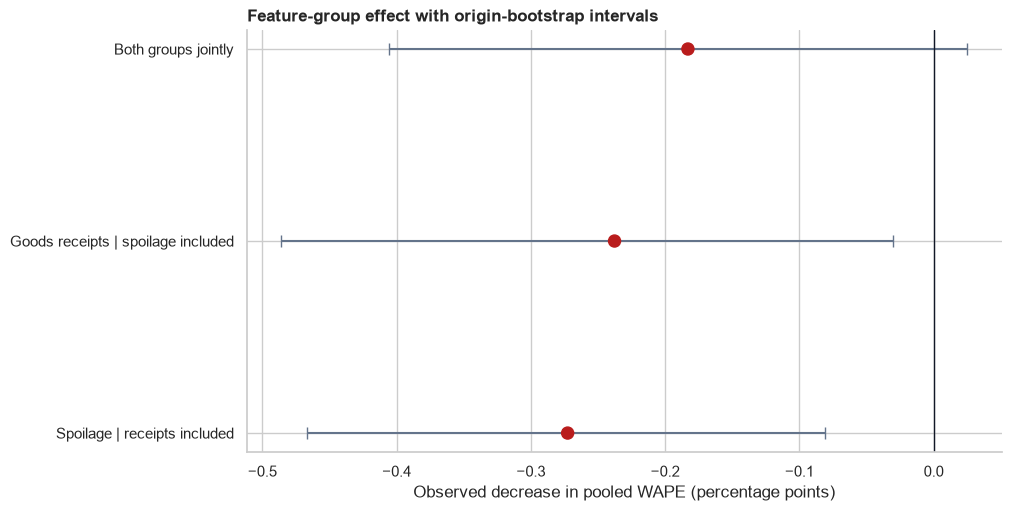

In [7]:
fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
plot_effects = effects.iloc[[0, 1, 4]].sort_values('error_decrease_pp')
xerr = np.vstack([
    plot_effects.error_decrease_pp - plot_effects.bootstrap_95_low_pp,
    plot_effects.bootstrap_95_high_pp - plot_effects.error_decrease_pp,
])
colors = np.where(plot_effects.error_decrease_pp.gt(0), '#15803d', '#b91c1c')
ax.errorbar(
    plot_effects.error_decrease_pp, plot_effects.comparison, xerr=xerr,
    fmt='none', ecolor='#64748b', capsize=4, linewidth=1.5,
)
ax.scatter(plot_effects.error_decrease_pp, plot_effects.comparison, c=colors, s=75, zorder=3)
ax.axvline(0, color='#111827', linewidth=1)
ax.set_xlabel('Observed decrease in pooled WAPE (percentage points)')
ax.set_ylabel('')
ax.set_title('Feature-group effect with origin-bootstrap intervals', loc='left', weight='bold')
sns.despine(fig=fig)
plt.show()

## Two-stage diagnostics

Brier score isolates occurrence-probability accuracy on all active rows. Conditional quantity MAE is calculated only where actual demand is positive, matching the target population of the quantity stage. These metrics help locate which stage drives any final-forecast difference.

In [8]:
stage_rows = []
for model, group in active.groupby('model', observed=True, sort=False):
    positive = group.actual.gt(0)
    stage_rows.append({
        'model': model,
        'variant': VARIANT_LABELS[model],
        'brier_score': np.mean((group.occurrence_probability - positive.astype(float)) ** 2),
        'actual_occurrence_rate': positive.mean(),
        'predicted_occurrence_rate': group.occurrence_probability.mean(),
        'conditional_quantity_mae_kg': np.mean(np.abs(
            group.loc[positive, 'positive_quantity_forecast']
            - group.loc[positive, 'actual']
        )),
        'actual_positive_mean_kg': group.loc[positive, 'actual'].mean(),
        'predicted_positive_mean_kg': group.loc[positive, 'positive_quantity_forecast'].mean(),
    })
stage_diagnostics = pd.DataFrame(stage_rows).sort_values('brier_score')
display(stage_diagnostics.drop(columns='model').style.format({
    'brier_score': '{:.5f}', 'actual_occurrence_rate': '{:.3%}',
    'predicted_occurrence_rate': '{:.3%}',
    'conditional_quantity_mae_kg': '{:.4f}',
    'actual_positive_mean_kg': '{:.4f}',
    'predicted_positive_mean_kg': '{:.4f}',
}))

,variant,brier_score,actual_occurrence_rate,predicted_occurrence_rate,conditional_quantity_mae_kg,actual_positive_mean_kg,predicted_positive_mean_kg
1,Without spoilage,0.11132,37.794%,38.197%,1.2284,2.6898,2.6577
0,All features,0.11140,37.794%,38.280%,1.2335,2.6898,2.6529
2,Without goods receipts,0.11167,37.794%,38.296%,1.2280,2.6898,2.6457
3,Without both groups,0.11172,37.794%,38.274%,1.2291,2.6898,2.6311


## Segment sensitivity and full-model importance

Segment WAPE differences show whether a globally small result hides a useful effect in one sourcing/category group. Gain importance from the all-feature model is reported only as supporting context; the ablation above remains the evidence for changes in forecast error.

In [9]:
segmented = segment_wape(forecasts.assign(
    business_segment=forecasts.sourcing_group + ' ' + forecasts.category_id.astype(str)
), 'business_segment')
segment_wide = segmented.pivot(
    index='business_segment', columns='model', values='pooled_wape'
)
segment_effects = pd.DataFrame({
    'spoilage_error_decrease_pp': 100 * (segment_wide.without_spoilage - segment_wide.all_features),
    'goods_receipts_error_decrease_pp': 100 * (segment_wide.without_goods_receipts - segment_wide.all_features),
    'both_groups_error_decrease_pp': 100 * (segment_wide.without_both_groups - segment_wide.all_features),
}).reset_index()
display(segment_effects.style.format({
    'spoilage_error_decrease_pp': '{:+.3f}',
    'goods_receipts_error_decrease_pp': '{:+.3f}',
    'both_groups_error_decrease_pp': '{:+.3f}',
}))

full_importance = feature_importance.loc[feature_importance.model.eq('all_features')].copy()
full_importance['feature_group'] = np.select(
    [
        full_importance.feature.isin(SPOILAGE_FEATURES),
        full_importance.feature.isin(GOODS_RECEIPT_FEATURES),
    ],
    ['Spoilage', 'Goods receipts'],
    default='Other features',
)
group_importance = (
    full_importance.groupby(
        ['evaluation_origin', 'stage', 'feature_group'], observed=True
    ).gain_share.sum().rename('group_gain_share').reset_index()
    .groupby(['stage', 'feature_group'], observed=True)
    .agg(mean_gain_share=('group_gain_share', 'mean'))
    .reset_index()
)
display(group_importance.style.format({'mean_gain_share': '{:.2%}'}))

,business_segment,spoilage_error_decrease_pp,goods_receipts_error_decrease_pp,both_groups_error_decrease_pp
0,FCM 890,-1.919,-0.192,+4.066
1,FCM 900,-0.083,+0.813,+1.044
2,Pseudo 890,-0.275,-0.263,-0.218
3,Pseudo 900,-0.010,+1.218,+0.379


,stage,feature_group,mean_gain_share
0,occurrence,Goods receipts,0.14%
1,occurrence,Other features,99.86%
2,occurrence,Spoilage,0.00%
3,positive_quantity,Goods receipts,0.02%
4,positive_quantity,Other features,99.98%
5,positive_quantity,Spoilage,0.01%


## Data-driven conclusion

In [10]:
def verdict(row):
    if row.bootstrap_95_low_pp > 0:
        return 'decreased error consistently across the origin bootstrap'
    if row.bootstrap_95_high_pp < 0:
        return 'increased error consistently across the origin bootstrap'
    return 'had an inconclusive effect across origins'

requested = effects.iloc[:2]
lines = [
    f"- **{row.comparison.split(' |')[0]}:** {row.error_decrease_pp:+.3f} WAPE pp; "
    f"95% origin-bootstrap interval [{row.bootstrap_95_low_pp:+.3f}, "
    f"{row.bootstrap_95_high_pp:+.3f}] pp. It {verdict(row)}."
    for row in requested.itertuples(index=False)
]
joint = effects.iloc[4]
lines.append(
    f"- **Both groups jointly:** {joint.error_decrease_pp:+.3f} WAPE pp; "
    f"95% origin-bootstrap interval [{joint.bootstrap_95_low_pp:+.3f}, "
    f"{joint.bootstrap_95_high_pp:+.3f}] pp."
)
display(Markdown(
    'Positive values mean the feature group reduced error.\n\n' + '\n'.join(lines)
))

Positive values mean the feature group reduced error.

- **Spoilage:** -0.273 WAPE pp; 95% origin-bootstrap interval [-0.467, -0.081] pp. It increased error consistently across the origin bootstrap.
- **Goods receipts:** -0.238 WAPE pp; 95% origin-bootstrap interval [-0.486, -0.030] pp. It increased error consistently across the origin bootstrap.
- **Both groups jointly:** -0.183 WAPE pp; 95% origin-bootstrap interval [-0.406, +0.025] pp.